In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/city_day.csv')

# Display the first 5 rows
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
# Check the dataset dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Display column names
print("\nColumns:")
print(df.columns.tolist())

Rows: 29531
Columns: 16

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


In [ ]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [ ]:
# Check missing values
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [ ]:
# Missing value analysis

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Missing Percentage': missing_percentage
})

missing_summary = missing_summary.sort_values(
    by='Missing Percentage',
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
Xylene,18109,61.322001
PM10,11140,37.723071
NH3,10328,34.973418
Toluene,8041,27.229014
Benzene,5623,19.041008
AQI,4681,15.851139
AQI_Bucket,4681,15.851139
PM2.5,4598,15.570079
NOx,4185,14.171549
O3,4022,13.619586


In [ ]:
# Check for duplicate records

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,24933.0,67.450578,64.661449,0.04,28.820,48.57,80.5900,949.99
PM10,18391.0,118.127103,90.605110,0.01,56.255,95.68,149.7450,1000.00
NO,25949.0,17.574730,22.785846,0.02,5.630,9.89,19.9500,390.68
NO2,25946.0,28.560659,24.474746,0.01,11.750,21.69,37.6200,362.21
NOx,25346.0,32.309123,31.646011,0.00,12.820,23.52,40.1275,467.63
NH3,19203.0,23.483476,25.684275,0.01,8.580,15.85,30.0200,352.89
CO,27472.0,2.248598,6.962884,0.00,0.510,0.89,1.4500,175.81
SO2,25677.0,14.531977,18.133775,0.01,5.670,9.16,15.2200,193.86
O3,25509.0,34.491430,21.694928,0.01,18.860,30.84,45.5700,257.73
Benzene,23908.0,3.280840,15.811136,0.00,0.120,1.07,3.0800,455.03


In [ ]:
# Distribution of the target variable

print("AQI Bucket Distribution:")
print(df["AQI_Bucket"].value_counts(dropna=False))

AQI Bucket Distribution:
AQI_Bucket
Moderate        8829
Satisfactory    8224
NaN             4681
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


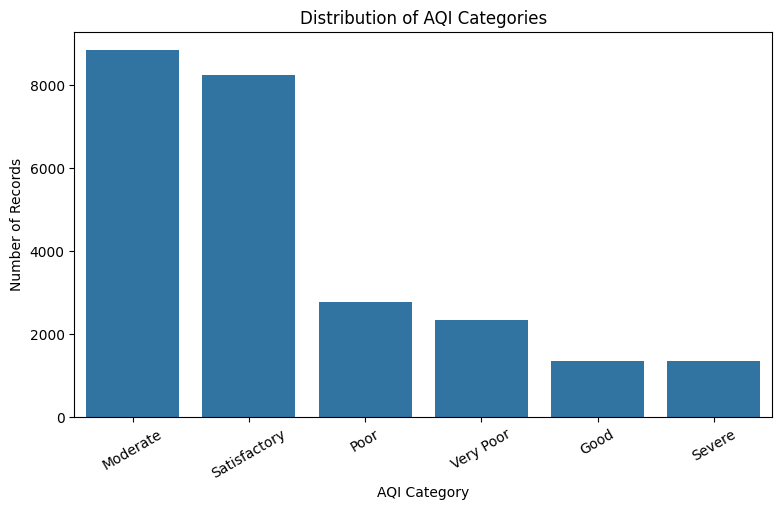

In [ ]:
# Visualize AQI category distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="AQI_Bucket",
    order=df["AQI_Bucket"].value_counts().index
)

plt.title("Distribution of AQI Categories")
plt.xlabel("AQI Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)
plt.show()

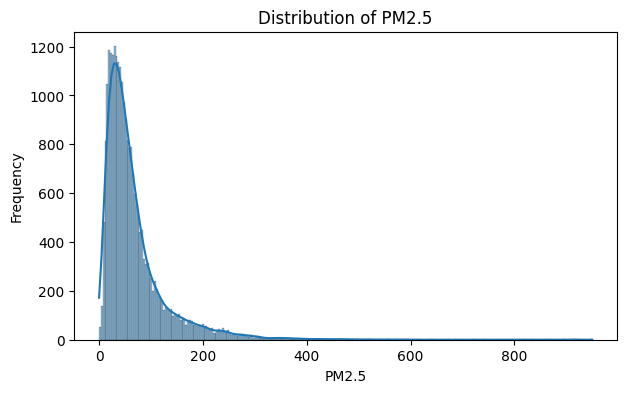

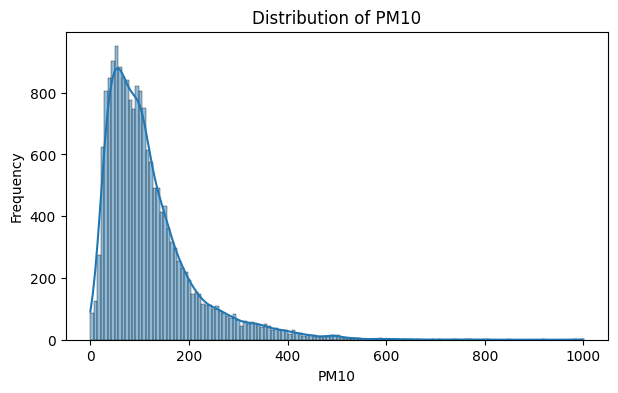

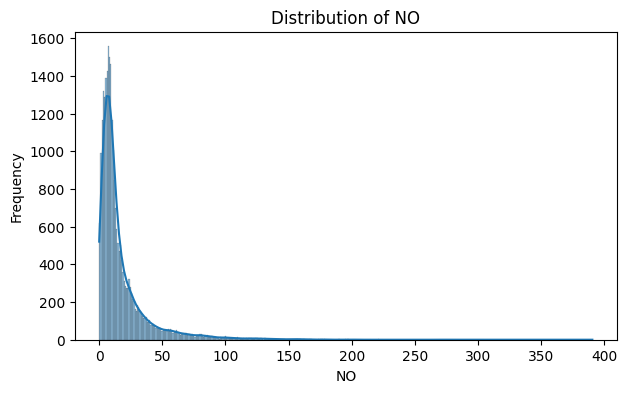

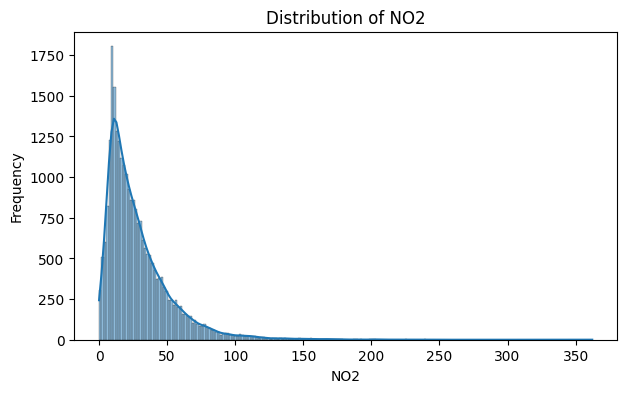

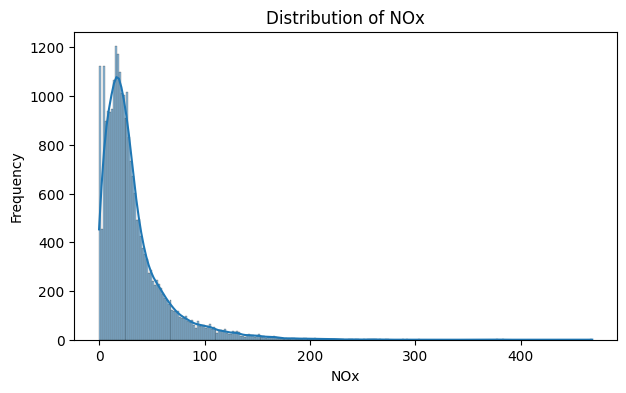

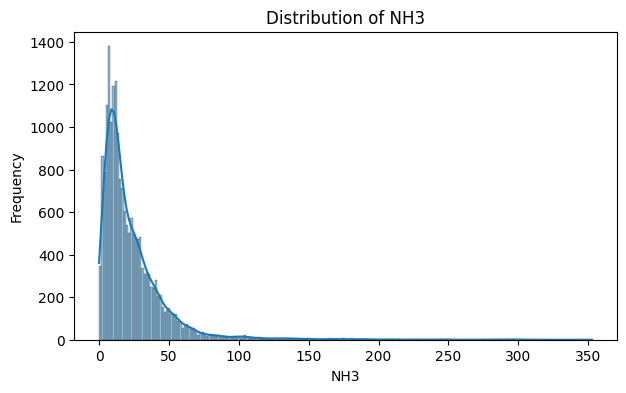

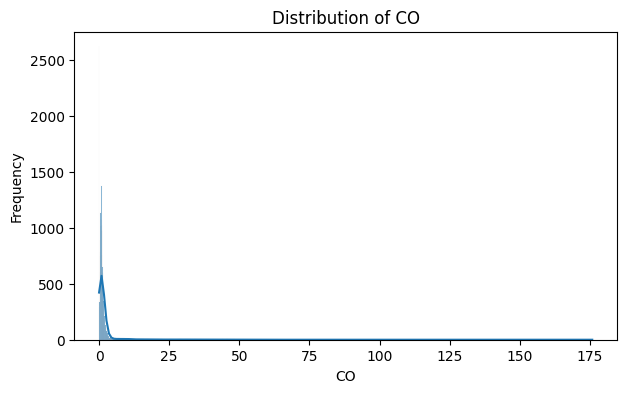

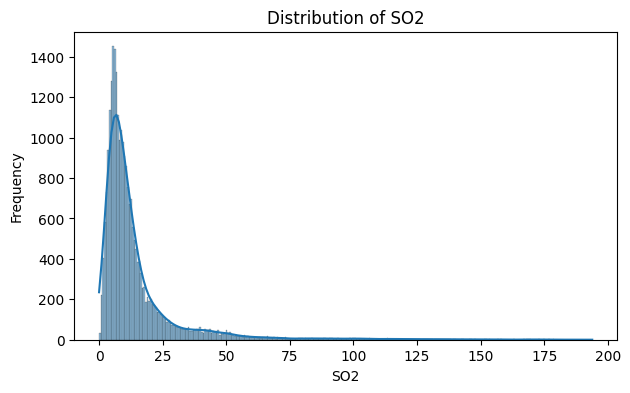

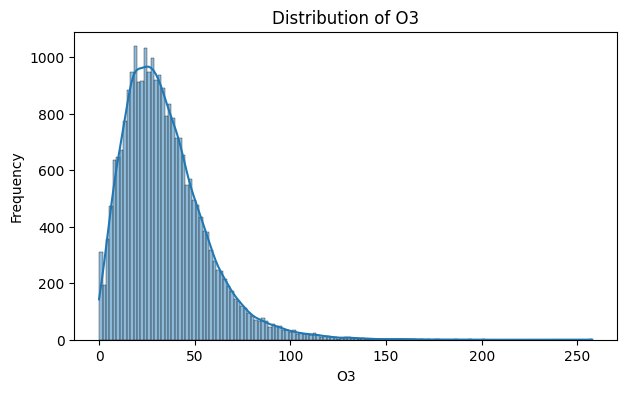

In [ ]:
# Distribution of major air pollutants

pollutants = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3"
]

for column in pollutants:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[column].dropna(), kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

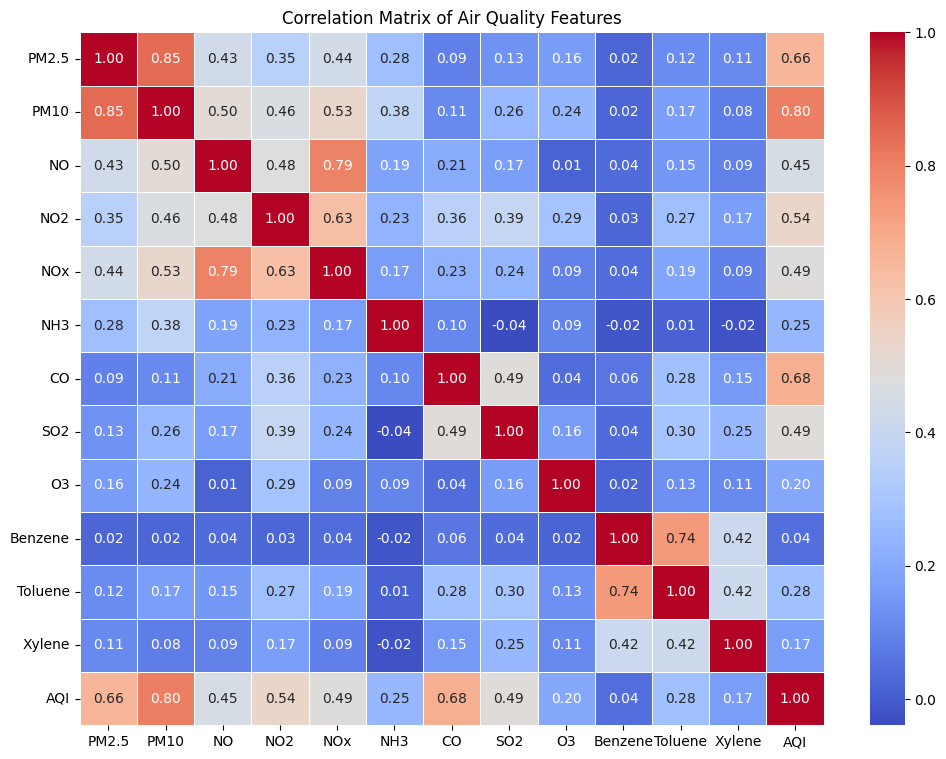

In [ ]:
# Correlation between numerical features

plt.figure(figsize=(12, 9))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Air Quality Features")
plt.show()

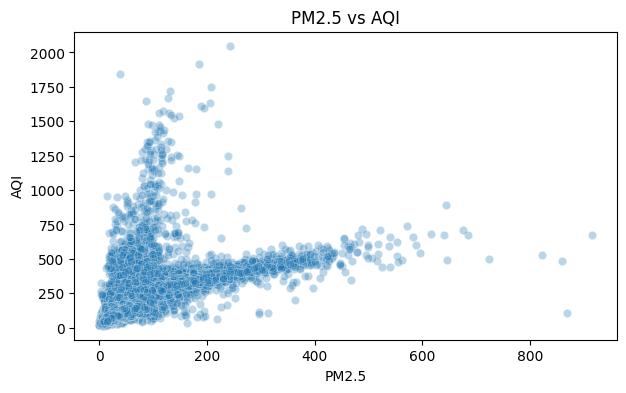

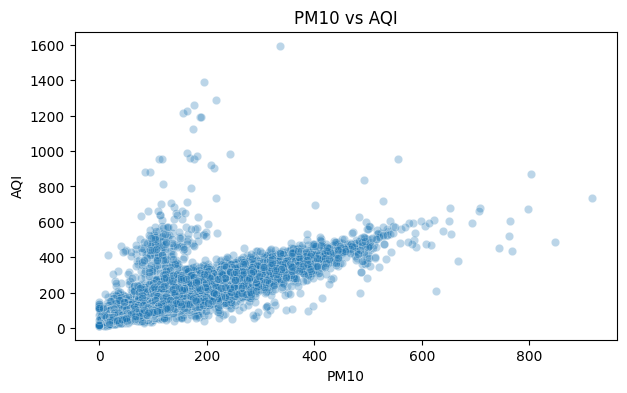

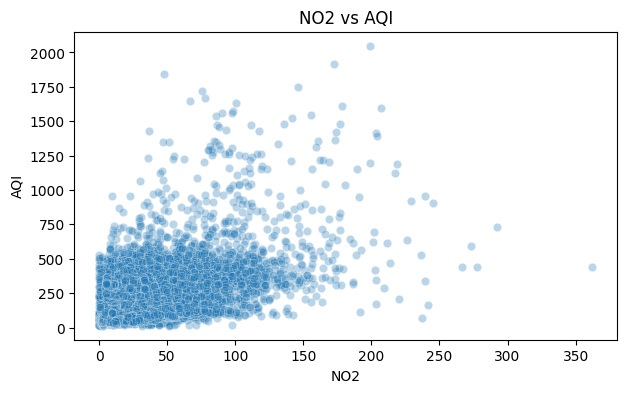

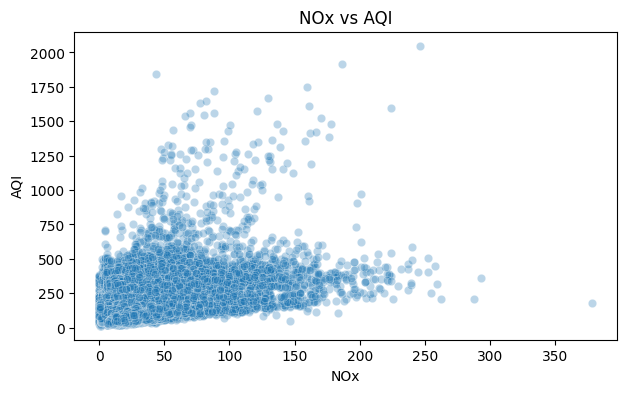

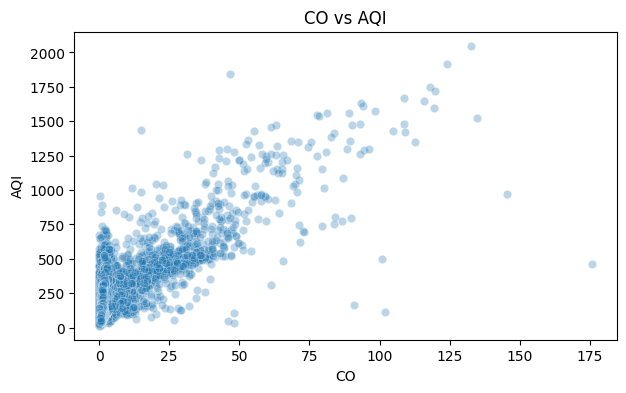

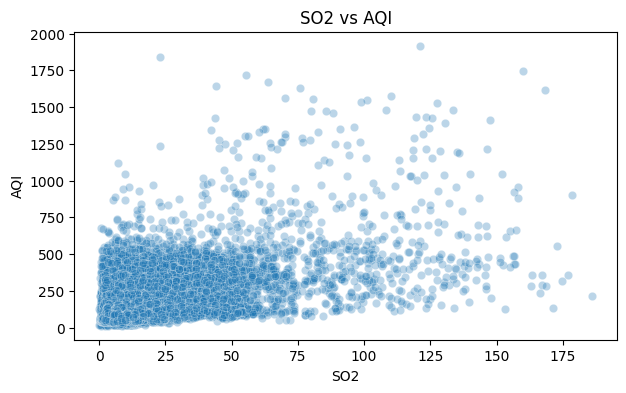

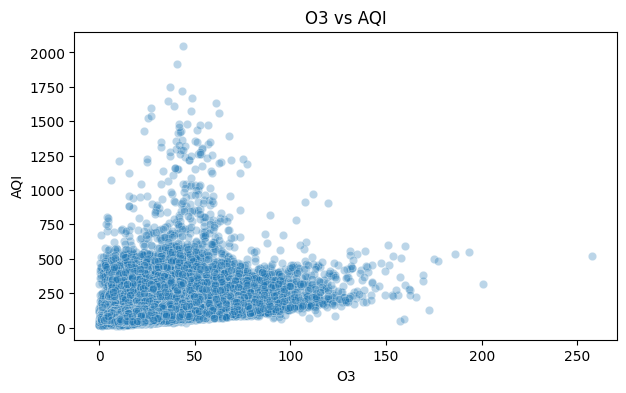

In [ ]:
# AQI relationship with major pollutants

major_pollutants = ["PM2.5", "PM10", "NO2", "NOx", "CO", "SO2", "O3"]

for column in major_pollutants:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(
        data=df,
        x=column,
        y="AQI",
        alpha=0.3
    )
    plt.title(f"{column} vs AQI")
    plt.xlabel(column)
    plt.ylabel("AQI")
    plt.show()

In [ ]:
# Check number of unique cities

print("Number of unique cities:", df["City"].nunique())
print("\nCities:")
print(df["City"].unique())

Number of unique cities: 26

Cities:
['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']


In [ ]:
# Convert Date to datetime format

df["Date"] = pd.to_datetime(df["Date"])

print("Date range:")
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

Date range:
Start: 2015-01-01 00:00:00
End: 2020-07-01 00:00:00


In [ ]:
# Number of records for each city

city_counts = df["City"].value_counts()

print(city_counts)

City
Ahmedabad             2009
Bengaluru             2009
Chennai               2009
Mumbai                2009
Lucknow               2009
Delhi                 2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Kochi                  162
Ernakulam              162
Aizawl                 113
Name: count, dtype: int64


In [ ]:
# Feature engineering from Date

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Create season feature
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["Season"] = df["Month"].apply(get_season)

# Display the new features
df[["Date", "Year", "Month", "Day", "DayOfWeek", "Season"]].head(10)

,Date,Year,Month,Day,DayOfWeek,Season
0,2015-01-01,2015,1,1,3,Winter
1,2015-01-02,2015,1,2,4,Winter
2,2015-01-03,2015,1,3,5,Winter
3,2015-01-04,2015,1,4,6,Winter
4,2015-01-05,2015,1,5,0,Winter
5,2015-01-06,2015,1,6,1,Winter
6,2015-01-07,2015,1,7,2,Winter
7,2015-01-08,2015,1,8,3,Winter
8,2015-01-09,2015,1,9,4,Winter
9,2015-01-10,2015,1,10,5,Winter


In [ ]:
# Check for physically invalid negative values

pollutant_columns = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene"
]

negative_values = {}

for column in pollutant_columns:
    count = (df[column] < 0).sum()
    negative_values[column] = count

negative_summary = pd.Series(negative_values)

print("Negative values found in each pollutant:")
print(negative_summary)

Negative values found in each pollutant:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64


In [ ]:
# Check for invalid AQI values

print("Negative AQI values:", (df["AQI"] < 0).sum())
print("Minimum AQI:", df["AQI"].min())
print("Maximum AQI:", df["AQI"].max())

Negative AQI values: 0
Minimum AQI: 13.0
Maximum AQI: 2049.0


In [ ]:
# Check for outliers using the IQR method

outlier_summary = {}

for column in pollutant_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    outlier_summary[column] = outliers

outlier_summary = pd.Series(outlier_summary).sort_values(ascending=False)

print("Number of potential outliers in each pollutant:")
print(outlier_summary)

Number of potential outliers in each pollutant:
SO2        2578
CO         2475
NO         2459
Toluene    2427
PM2.5      1982
NOx        1868
Benzene    1668
NO2        1188
Xylene     1119
PM10       1057
NH3        1015
O3          713
dtype: int64


In [ ]:
# Remove rows where the target variable is missing

print("Rows before removing missing target:", len(df))

df = df.dropna(subset=["AQI_Bucket"]).copy()

print("Rows after removing missing target:", len(df))
print("Rows removed:", 29531 - len(df))

Rows before removing missing target: 29531
Rows after removing missing target: 24850
Rows removed: 4681


In [ ]:
# Remove AQI because AQI is directly related to AQI_Bucket
# Keeping AQI would cause target leakage

df = df.drop(columns=["AQI"])

print("AQI removed.")
print("Remaining columns:")
print(df.columns.tolist())

AQI removed.
Remaining columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI_Bucket', 'Year', 'Month', 'Day', 'DayOfWeek', 'Season']


In [ ]:
# Confirm that there are no missing target values

print(df["AQI_Bucket"].isnull().sum())
print("\nTarget distribution:")
print(df["AQI_Bucket"].value_counts())

0

Target distribution:
AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


In [ ]:
# Separate features (X) and target (y)

X = df.drop(columns=["AQI_Bucket"])
y = df["AQI_Bucket"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (24850, 19)
Target shape: (24850,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 19880
Test samples: 4970


In [ ]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training target distribution:
AQI_Bucket
Moderate        0.355
Satisfactory    0.331
Poor            0.112
Very Poor       0.094
Good            0.054
Severe          0.054
Name: proportion, dtype: float64

Test target distribution:
AQI_Bucket
Moderate        0.355
Satisfactory    0.331
Poor            0.112
Very Poor       0.094
Good            0.054
Severe          0.054
Name: proportion, dtype: float64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify feature types

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

Categorical features:
['City', 'Season']


In [ ]:
# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Leakage-safe preprocessing pipeline created successfully.")

Leakage-safe preprocessing pipeline created successfully.


In [ ]:
# Check class imbalance in the training data

class_counts = y_train.value_counts()
class_percentages = y_train.value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

print(imbalance_summary)

              Count  Percentage
AQI_Bucket                     
Moderate       7063       35.53
Satisfactory   6579       33.09
Poor           2225       11.19
Very Poor      1870        9.41
Good           1073        5.40
Severe         1070        5.38


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression baseline pipeline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train the baseline
baseline_model.fit(X_train, y_train)

print("Logistic Regression baseline trained successfully.")

Logistic Regression baseline trained successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predictions
y_pred_baseline = baseline_model.predict(X_test)

# Calculate metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(
    y_test, y_pred_baseline, average="weighted", zero_division=0
)
baseline_recall = recall_score(
    y_test, y_pred_baseline, average="weighted", zero_division=0
)
baseline_f1 = f1_score(
    y_test, y_pred_baseline, average="weighted", zero_division=0
)

print("Logistic Regression Baseline Results")
print("------------------------------------")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, zero_division=0))

Logistic Regression Baseline Results
------------------------------------
Accuracy : 0.7227
Precision: 0.7562
Recall   : 0.7227
F1 Score : 0.7308

Classification Report:
              precision    recall  f1-score   support

        Good       0.40      0.87      0.55       268
    Moderate       0.82      0.73      0.77      1766
        Poor       0.57      0.72      0.64       556
Satisfactory       0.80      0.68      0.74      1645
      Severe       0.77      0.84      0.80       268
   Very Poor       0.75      0.70      0.73       467

    accuracy                           0.72      4970
   macro avg       0.69      0.76      0.70      4970
weighted avg       0.76      0.72      0.73      4970



<Figure size 800x600 with 0 Axes>

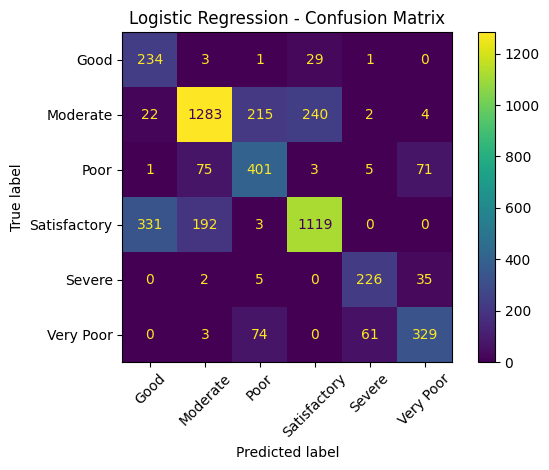

In [ ]:
# Confusion matrix for Logistic Regression

plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    xticks_rotation=45
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Train Random Forest
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
# Predictions
y_pred_rf = random_forest_model.predict(X_test)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(
    y_test, y_pred_rf, average="weighted", zero_division=0
)
rf_recall = recall_score(
    y_test, y_pred_rf, average="weighted", zero_division=0
)
rf_f1 = f1_score(
    y_test, y_pred_rf, average="weighted", zero_division=0
)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Results
---------------------
Accuracy : 0.8133
Precision: 0.8121
Recall   : 0.8133
F1 Score : 0.8112

Classification Report:
              precision    recall  f1-score   support

        Good       0.79      0.63      0.71       268
    Moderate       0.81      0.86      0.84      1766
        Poor       0.75      0.63      0.69       556
Satisfactory       0.84      0.86      0.85      1645
      Severe       0.87      0.79      0.83       268
   Very Poor       0.78      0.81      0.79       467

    accuracy                           0.81      4970
   macro avg       0.81      0.76      0.78      4970
weighted avg       0.81      0.81      0.81      4970



<Figure size 800x600 with 0 Axes>

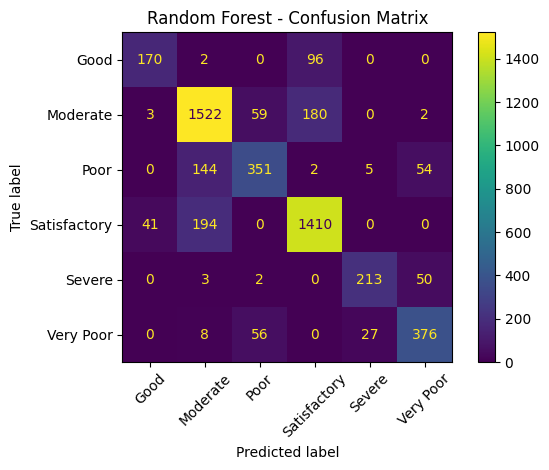

In [ ]:
plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    xticks_rotation=45
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
!pip install -q xgboost

In [ ]:
from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Class mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

Class mapping:
0 = Good
1 = Moderate
2 = Poor
3 = Satisfactory
4 = Severe
5 = Very Poor


In [ ]:
# Create XGBoost pipeline

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Train XGBoost
xgb_model.fit(X_train, y_train_encoded)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [ ]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Calculate metrics
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb)

xgb_precision = precision_score(
    y_test_encoded,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

xgb_recall = recall_score(
    y_test_encoded,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test_encoded,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

print("XGBoost Results")
print("----------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred_xgb,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

XGBoost Results
----------------
Accuracy : 0.8177
Precision: 0.8168
Recall   : 0.8177
F1 Score : 0.8170

Classification Report:
              precision    recall  f1-score   support

        Good       0.78      0.72      0.75       268
    Moderate       0.83      0.84      0.84      1766
        Poor       0.73      0.69      0.71       556
Satisfactory       0.84      0.86      0.85      1645
      Severe       0.86      0.82      0.84       268
   Very Poor       0.79      0.79      0.79       467

    accuracy                           0.82      4970
   macro avg       0.80      0.79      0.79      4970
weighted avg       0.82      0.82      0.82      4970



<Figure size 800x600 with 0 Axes>

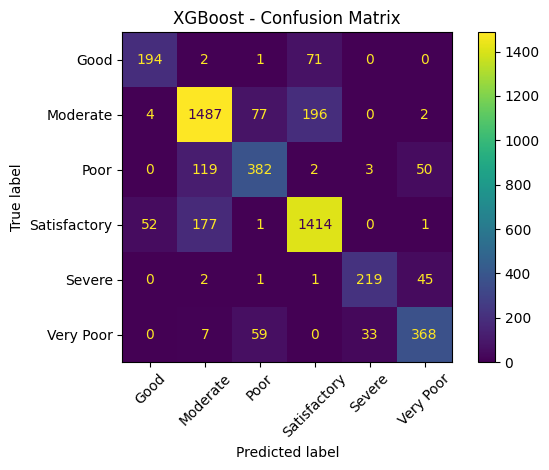

In [ ]:
plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred_xgb,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Random Forest pipeline for tuning
rf_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter search space
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

# Randomized search with 5-fold CV
rf_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=rf_param_grid,
    n_iter=8,
    scoring="f1_weighted",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{rf_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Random Forest parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30}

Best Cross-Validation F1 Score:
0.8049


In [ ]:
# Best tuned Random Forest
best_rf = rf_search.best_estimator_

# Predict on untouched test set
y_pred_rf_tuned = best_rf.predict(X_test)

rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)

rf_tuned_precision = precision_score(
    y_test,
    y_pred_rf_tuned,
    average="weighted",
    zero_division=0
)

rf_tuned_recall = recall_score(
    y_test,
    y_pred_rf_tuned,
    average="weighted",
    zero_division=0
)

rf_tuned_f1 = f1_score(
    y_test,
    y_pred_rf_tuned,
    average="weighted",
    zero_division=0
)

print("Tuned Random Forest Results")
print("---------------------------")
print(f"Accuracy : {rf_tuned_accuracy:.4f}")
print(f"Precision: {rf_tuned_precision:.4f}")
print(f"Recall   : {rf_tuned_recall:.4f}")
print(f"F1 Score : {rf_tuned_f1:.4f}")

Tuned Random Forest Results
---------------------------
Accuracy : 0.8147
Precision: 0.8140
Recall   : 0.8147
F1 Score : 0.8140


<Figure size 800x600 with 0 Axes>

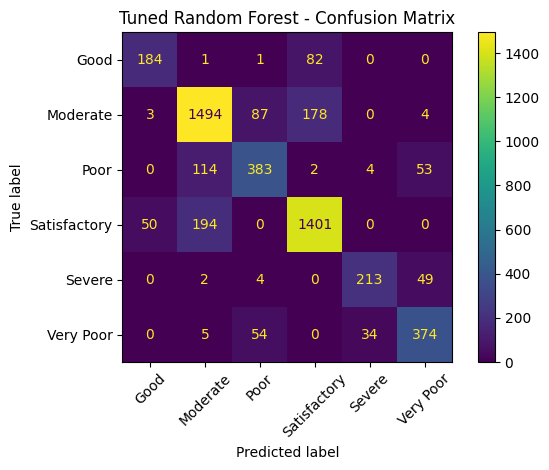

In [ ]:
plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_tuned,
    xticks_rotation=45
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# XGBoost pipeline for tuning
xgb_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter search space
xgb_param_grid = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

# Randomized search with 5-fold cross-validation
xgb_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring="f1_weighted",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train_encoded)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best XGBoost parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}

Best Cross-Validation F1 Score:
0.8086


In [ ]:
# Best tuned XGBoost
best_xgb = xgb_search.best_estimator_

# Predict on untouched test data
y_pred_xgb_tuned = best_xgb.predict(X_test)

xgb_tuned_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_xgb_tuned
)

xgb_tuned_precision = precision_score(
    y_test_encoded,
    y_pred_xgb_tuned,
    average="weighted",
    zero_division=0
)

xgb_tuned_recall = recall_score(
    y_test_encoded,
    y_pred_xgb_tuned,
    average="weighted",
    zero_division=0
)

xgb_tuned_f1 = f1_score(
    y_test_encoded,
    y_pred_xgb_tuned,
    average="weighted",
    zero_division=0
)

print("Tuned XGBoost Results")
print("---------------------")
print(f"Accuracy : {xgb_tuned_accuracy:.4f}")
print(f"Precision: {xgb_tuned_precision:.4f}")
print(f"Recall   : {xgb_tuned_recall:.4f}")
print(f"F1 Score : {xgb_tuned_f1:.4f}")

Tuned XGBoost Results
---------------------
Accuracy : 0.8201
Precision: 0.8190
Recall   : 0.8201
F1 Score : 0.8190


<Figure size 800x600 with 0 Axes>

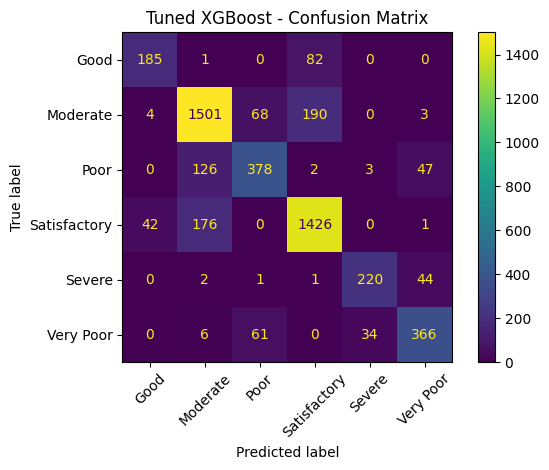

In [ ]:
plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred_xgb_tuned,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("Tuned XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import StackingClassifier

# Base learners
stacking_estimators = [
    (
        "logistic",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    ),
    (
        "random_forest",
        RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    ),
    (
        "xgboost",
        XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            num_class=len(label_encoder.classes_),
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        )
    )
]

# Stacking pipeline
stacking_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        StackingClassifier(
            estimators=stacking_estimators,
            final_estimator=LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            ),
            cv=5,
            stack_method="predict_proba",
            n_jobs=-1
        )
    )
])

print("Stacking model created successfully.")

Stacking model created successfully.


In [ ]:
# Train stacking ensemble

stacking_model.fit(X_train, y_train_encoded)

print("Stacking model trained successfully.")

Stacking model trained successfully.


In [ ]:
# Predictions
y_pred_stack = stacking_model.predict(X_test)

stack_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_stack
)

stack_precision = precision_score(
    y_test_encoded,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

stack_recall = recall_score(
    y_test_encoded,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

stack_f1 = f1_score(
    y_test_encoded,
    y_pred_stack,
    average="weighted",
    zero_division=0
)

print("Stacking Ensemble Results")
print("-------------------------")
print(f"Accuracy : {stack_accuracy:.4f}")
print(f"Precision: {stack_precision:.4f}")
print(f"Recall   : {stack_recall:.4f}")
print(f"F1 Score : {stack_f1:.4f}")

Stacking Ensemble Results
-------------------------
Accuracy : 0.8109
Precision: 0.8170
Recall   : 0.8109
F1 Score : 0.8125


<Figure size 800x600 with 0 Axes>

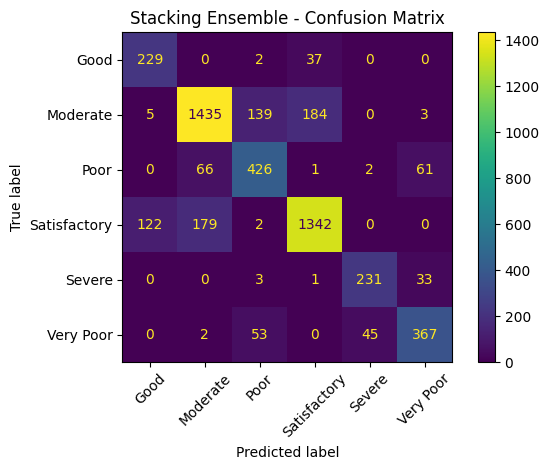

In [ ]:
plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred_stack,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("Stacking Ensemble - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Model comparison

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost",
        "Tuned XGBoost",
        "Stacking Ensemble"
    ],
    "Accuracy": [
        baseline_accuracy,
        rf_accuracy,
        rf_tuned_accuracy,
        xgb_accuracy,
        xgb_tuned_accuracy,
        stack_accuracy
    ],
    "Precision": [
        baseline_precision,
        rf_precision,
        rf_tuned_precision,
        xgb_precision,
        xgb_tuned_precision,
        stack_precision
    ],
    "Recall": [
        baseline_recall,
        rf_recall,
        rf_tuned_recall,
        xgb_recall,
        xgb_tuned_recall,
        stack_recall
    ],
    "F1 Score": [
        baseline_f1,
        rf_f1,
        rf_tuned_f1,
        xgb_f1,
        xgb_tuned_f1,
        stack_f1
    ]
})

results = results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned XGBoost,0.8201,0.8190,0.8201,0.8190
1,XGBoost,0.8177,0.8168,0.8177,0.8170
2,Tuned Random Forest,0.8147,0.8140,0.8147,0.8140
3,Stacking Ensemble,0.8109,0.8170,0.8109,0.8125
4,Random Forest,0.8133,0.8121,0.8133,0.8112
5,Logistic Regression,0.7227,0.7562,0.7227,0.7308


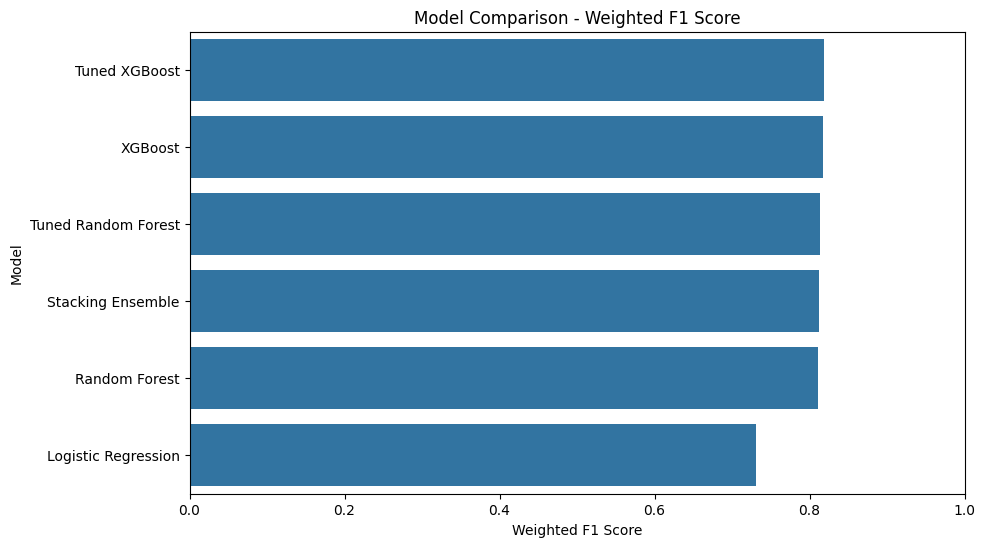

In [ ]:
# Compare model F1 scores

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="F1 Score",
    y="Model"
)

plt.title("Model Comparison - Weighted F1 Score")
plt.xlabel("Weighted F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

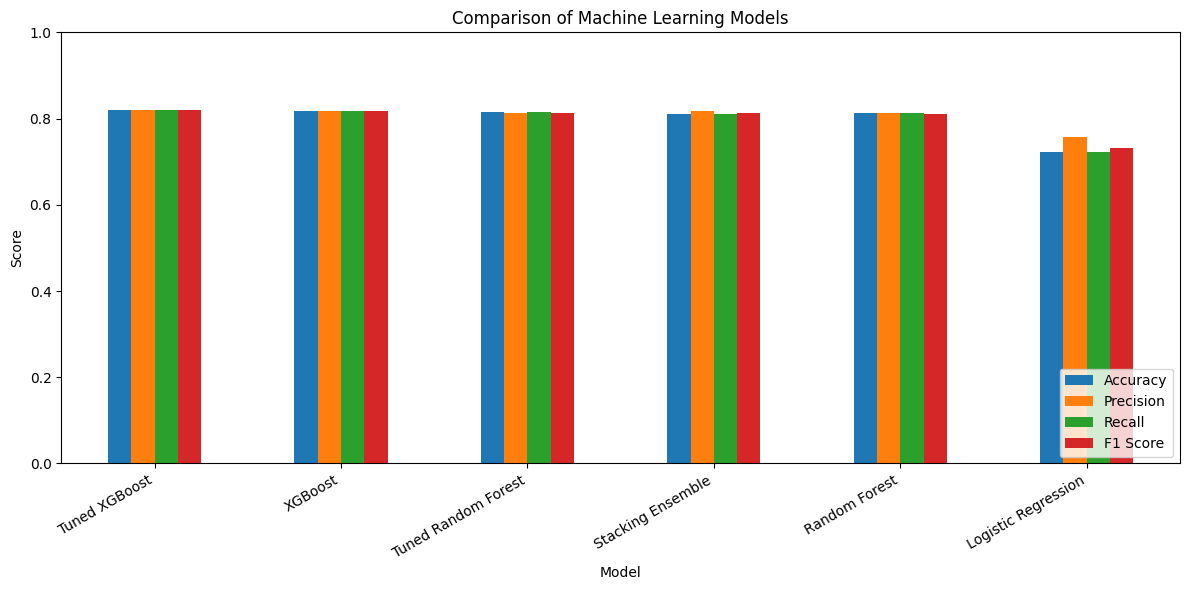

In [ ]:
# Visual comparison of evaluation metrics

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize test labels for multiclass ROC-AUC
y_test_binary = label_binarize(
    y_test_encoded,
    classes=np.arange(len(label_encoder.classes_))
)

# Get prediction probabilities
baseline_proba = baseline_model.predict_proba(X_test)
rf_proba = random_forest_model.predict_proba(X_test)
rf_tuned_proba = best_rf.predict_proba(X_test)
xgb_proba = xgb_model.predict_proba(X_test)
xgb_tuned_proba = best_xgb.predict_proba(X_test)
stack_proba = stacking_model.predict_proba(X_test)

# Calculate multiclass ROC-AUC
roc_auc_results = {
    "Logistic Regression": roc_auc_score(
        y_test_binary, baseline_proba, multi_class="ovr", average="weighted"
    ),
    "Random Forest": roc_auc_score(
        y_test_binary, rf_proba, multi_class="ovr", average="weighted"
    ),
    "Tuned Random Forest": roc_auc_score(
        y_test_binary, rf_tuned_proba, multi_class="ovr", average="weighted"
    ),
    "XGBoost": roc_auc_score(
        y_test_binary, xgb_proba, multi_class="ovr", average="weighted"
    ),
    "Tuned XGBoost": roc_auc_score(
        y_test_binary, xgb_tuned_proba, multi_class="ovr", average="weighted"
    ),
    "Stacking Ensemble": roc_auc_score(
        y_test_binary, stack_proba, multi_class="ovr", average="weighted"
    )
}

roc_auc_results = pd.Series(
    roc_auc_results,
    name="Weighted ROC-AUC"
).sort_values(ascending=False)

roc_auc_results.round(4)

,Weighted ROC-AUC
Tuned XGBoost,0.9639
XGBoost,0.9632
Tuned Random Forest,0.9625
Random Forest,0.9623
Stacking Ensemble,0.9595
Logistic Regression,0.9332


In [ ]:
# Identify the best model based on weighted F1 score

best_model_name = results.loc[0, "Model"]

print("Best model based on weighted F1 Score:")
print(best_model_name)

print("\nBest F1 Score:")
print(round(results.loc[0, "F1 Score"], 4))

print("\nBest ROC-AUC:")
print(round(roc_auc_results.loc[best_model_name], 4))

Best model based on weighted F1 Score:
Tuned XGBoost

Best F1 Score:
0.819

Best ROC-AUC:
0.9639


In [ ]:
!pip install -q shap

In [ ]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
# Extract the trained XGBoost model and preprocessing pipeline

best_xgb_preprocessor = best_xgb.named_steps["preprocessor"]
best_xgb_estimator = best_xgb.named_steps["model"]

# Transform the test data using the already-fitted preprocessing pipeline
X_test_transformed = best_xgb_preprocessor.transform(X_test)

# Convert to dense format for SHAP if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get feature names after preprocessing
feature_names = best_xgb_preprocessor.get_feature_names_out()

print("Transformed test shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

Transformed test shape: (4970, 42)
Number of feature names: 42


In [ ]:
import shap

# Create SHAP TreeExplainer for XGBoost
explainer = shap.TreeExplainer(best_xgb_estimator)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values calculated successfully.")
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values calculated successfully.
SHAP values shape: (4970, 42, 6)


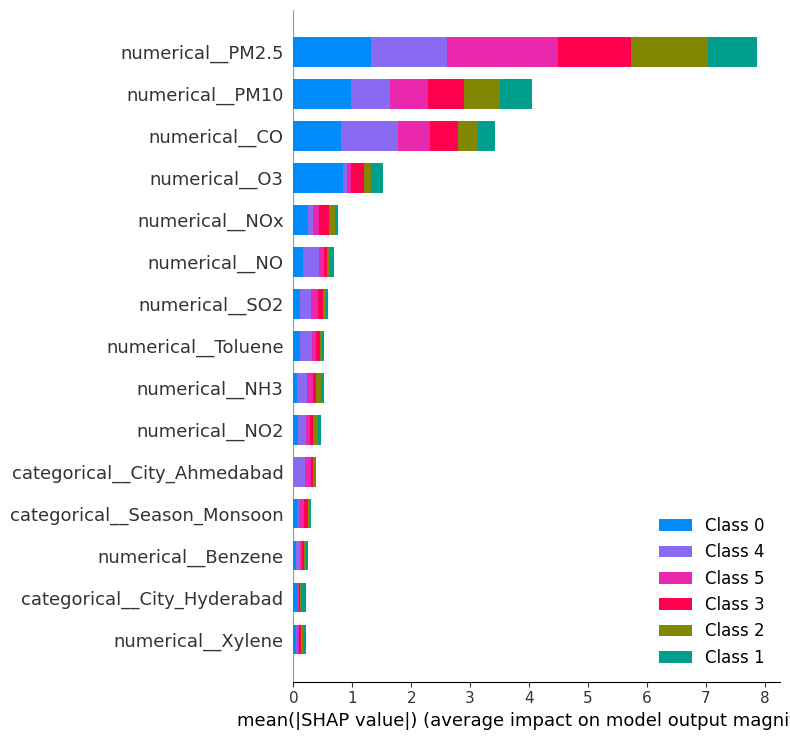

In [ ]:
# Global SHAP feature importance

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15
)

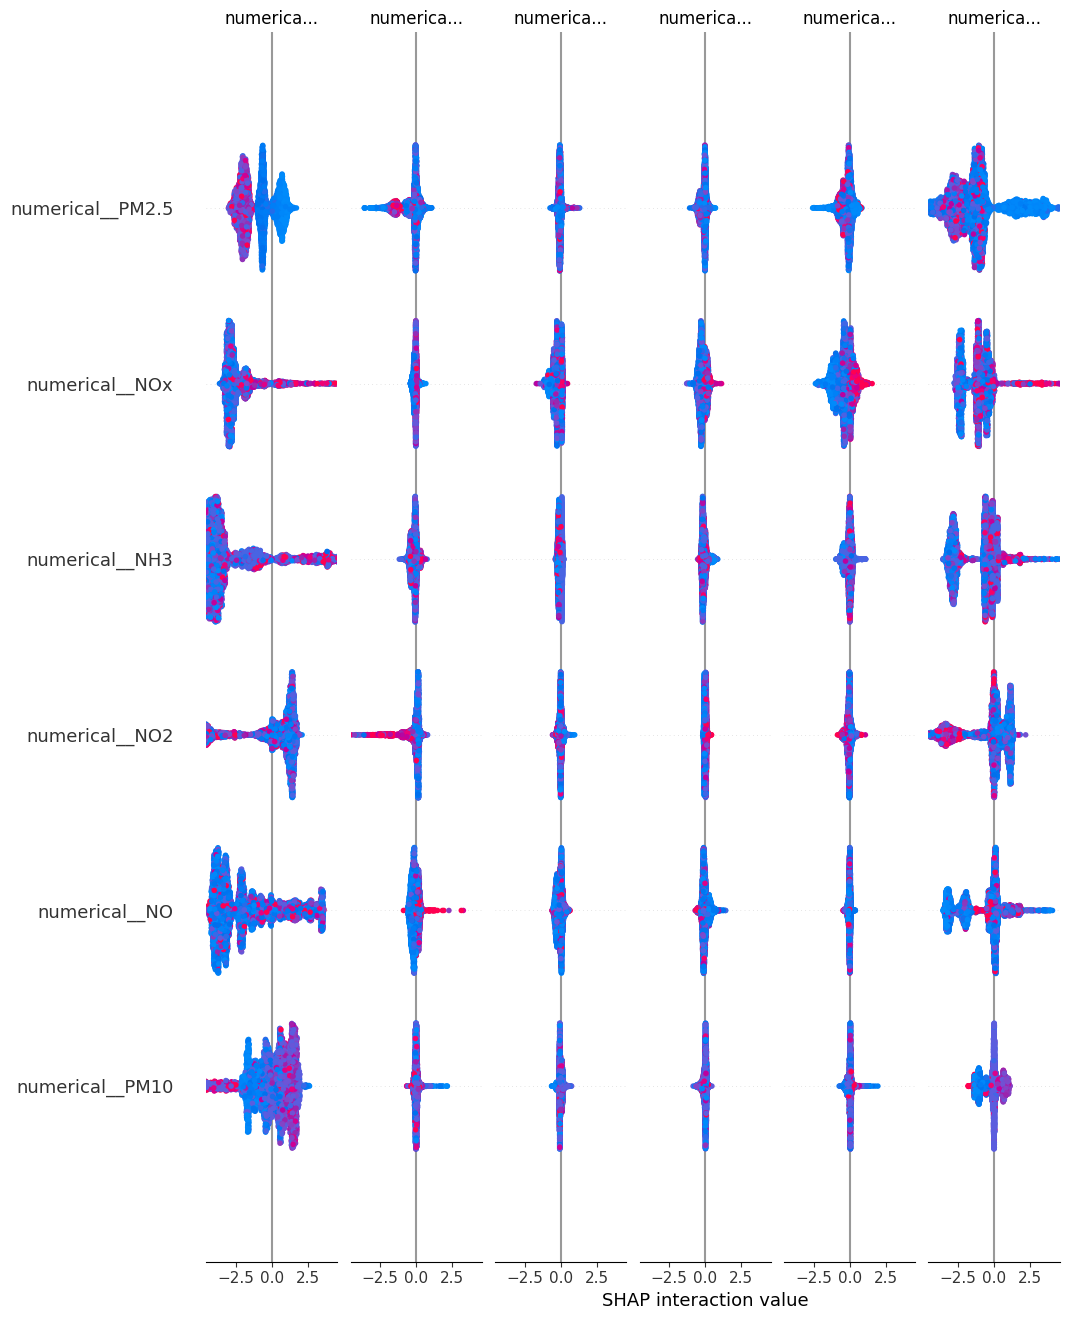

In [ ]:
# Detailed SHAP summary plot

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

In [ ]:
# Create a realistic synthetic air-quality record for the live demo

demo_data = pd.DataFrame({
    "City": ["Bengaluru"],
    "Date": [pd.Timestamp("2020-01-15")],
    "PM2.5": [85.0],
    "PM10": [145.0],
    "NO": [18.0],
    "NO2": [42.0],
    "NOx": [55.0],
    "NH3": [25.0],
    "CO": [1.2],
    "SO2": [18.0],
    "O3": [35.0],
    "Benzene": [3.0],
    "Toluene": [12.0],
    "Xylene": [2.0]
})

# Create the same date-derived features used during training
demo_data["Year"] = demo_data["Date"].dt.year
demo_data["Month"] = demo_data["Date"].dt.month
demo_data["Day"] = demo_data["Date"].dt.day
demo_data["DayOfWeek"] = demo_data["Date"].dt.dayofweek

# Create season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

demo_data["Season"] = demo_data["Month"].apply(get_season)

print("Synthetic air-quality record:")
display(demo_data)

Synthetic air-quality record:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,Year,Month,Day,DayOfWeek,Season
0,Bengaluru,2020-01-15,85.0,145.0,18.0,42.0,55.0,25.0,1.2,18.0,35.0,3.0,12.0,2.0,2020,1,15,2,Winter


In [ ]:
# Select one test record for individual explanation

sample_index = 0

X_sample = X_test.iloc[[sample_index]]
y_actual = y_test.iloc[sample_index]

# Predict the AQI category
predicted_class_encoded = best_xgb.predict(X_sample)[0]
predicted_class = label_encoder.inverse_transform(
    [predicted_class_encoded]
)[0]

print("Actual AQI Category:", y_actual)
print("Predicted AQI Category:", predicted_class)

print("\nInput values:")
display(X_sample)

Actual AQI Category: Satisfactory
Predicted AQI Category: Satisfactory

Input values:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,Year,Month,Day,DayOfWeek,Season
13638,Gurugram,2019-04-18,31.04,69.43,11.09,13.84,17.12,NaN,0.56,2.45,33.67,0.0,0.0,NaN,2019,4,18,3,Summer


In [ ]:
# Predict AQI category

demo_prediction_encoded = best_xgb.predict(demo_data)[0]

demo_prediction = label_encoder.inverse_transform(
    [demo_prediction_encoded]
)[0]

demo_probabilities = best_xgb.predict_proba(demo_data)[0]

print("Predicted AQI Category:", demo_prediction)

print("\nPrediction probabilities:")

for category, probability in zip(
    label_encoder.classes_,
    demo_probabilities
):
    print(f"{category}: {probability:.4f}")

Predicted AQI Category: Moderate

Prediction probabilities:
Good: 0.0001
Moderate: 0.8978
Poor: 0.0907
Satisfactory: 0.0030
Severe: 0.0010
Very Poor: 0.0073


In [ ]:
# Display the prediction clearly

confidence = demo_probabilities[demo_prediction_encoded]

print("=" * 50)
print("        AIR QUALITY PREDICTION DEMO")
print("=" * 50)
print(f"City              : {demo_data['City'].iloc[0]}")
print(f"Date              : {demo_data['Date'].iloc[0].date()}")
print(f"Predicted Category: {demo_prediction}")
print(f"Model Confidence  : {confidence:.2%}")
print("=" * 50)

        AIR QUALITY PREDICTION DEMO
City              : Bengaluru
Date              : 2020-01-15
Predicted Category: Moderate
Model Confidence  : 89.78%


In [ ]:
# Transform the selected sample using the fitted preprocessing pipeline

X_sample_transformed = best_xgb_preprocessor.transform(X_sample)

if hasattr(X_sample_transformed, "toarray"):
    X_sample_transformed = X_sample_transformed.toarray()

# Get SHAP values for the selected sample
sample_shap = explainer.shap_values(X_sample_transformed)

print("Sample SHAP shape:", np.array(sample_shap).shape)

Sample SHAP shape: (1, 42, 6)


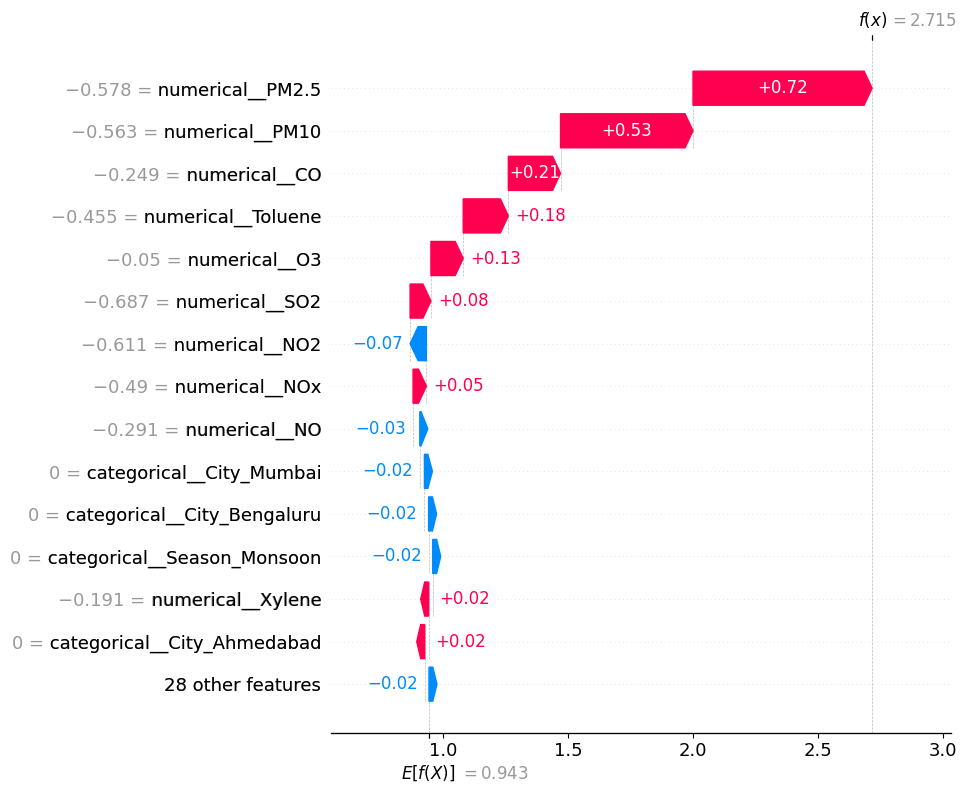

In [ ]:
# Create individual SHAP explanation for the predicted class

shap_array = np.array(sample_shap)

num_classes = len(label_encoder.classes_)

if shap_array.ndim == 3:
    # Shape: (samples, features, classes)
    class_shap_values = shap_array[0, :, predicted_class_encoded]
elif shap_array.ndim == 2 and shap_array.shape[0] == num_classes:
    # Shape: (classes, features)
    class_shap_values = shap_array[predicted_class_encoded]
elif shap_array.ndim == 2:
    # Binary/older format
    class_shap_values = shap_array[0]
else:
    raise ValueError(f"Unexpected SHAP shape: {shap_array.shape}")

# Obtain the base value for the predicted class
base_values = explainer.expected_value

if np.ndim(base_values) > 0:
    base_value = base_values[predicted_class_encoded]
else:
    base_value = base_values

# Create SHAP Explanation
individual_explanation = shap.Explanation(
    values=class_shap_values,
    base_values=base_value,
    data=X_sample_transformed[0],
    feature_names=feature_names
)

# Display waterfall plot
shap.plots.waterfall(
    individual_explanation,
    max_display=15
)

# **4)** **Ethics**, **and** **Responsible** **Use**
The final model is a tuned XGBoost classifier that predicts air-quality categories from pollutant measurements and contextual features. SHAP was used to explain the model at both global and individual levels. The global SHAP analysis identifies the features that have the greatest influence on predictions, while the individual explanation shows how different features contributed to a specific prediction.

## Bias and Fairness

The dataset contains observations from multiple Indian cities, but the number of observations is not evenly distributed across cities. Therefore, the model may perform better for cities with more historical data and less reliably for cities with fewer observations. Model performance should be evaluated across different cities before any real-world deployment.

## Privacy

The dataset contains environmental and air-quality measurements rather than personally identifiable information. Nevertheless, any future deployment involving additional location or sensor information should follow appropriate privacy and data-governance practices.

## Prediction Uncertainty

A machine-learning prediction is an estimate and should not be treated as a guaranteed measurement of air quality. Environmental conditions can change rapidly, and sensor measurements may contain noise or measurement errors.

## False Positives and False Negatives

A false positive occurs when the model predicts a more harmful air-quality category than the actual category. This could lead to unnecessary warnings or precautions.

A false negative occurs when the model predicts a safer category than the actual air-quality condition. This is potentially more serious because people may fail to take appropriate precautions during unhealthy pollution conditions.

Therefore, model evaluation should consider precision, recall, F1-score, ROC-AUC, and the confusion matrix rather than relying only on accuracy.

## Human Oversight

The model should be treated as a decision-support system rather than a replacement for official air-quality monitoring systems or environmental authorities. Human experts should validate important predictions before they are used for public warnings or policy decisions.

## Limitations

The model is trained on historical observations and may not generalize equally well to all locations or future environmental conditions. The dataset also contains missing measurements and uneven city representation. Extreme pollution observations may be genuine environmental events, so removing all outliers could discard meaningful information. The model should therefore be validated on additional and more recent data before real-world deployment.

## Responsible Deployment

The system should be used to support environmental awareness, monitoring, and decision-making. It should not be used as a medical diagnostic system or as the sole basis for public-health decisions.
